In [4]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import TfidfVectorizer 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [6]:
# collection data
df = pd.read_csv("decision_tree_dataset.csv")
# df
# 1. Fill missing Age with the average (median) age
df['Age'] = df['Age'].fillna(df['Age'].median())

# 2. Fill missing Embarked with the most common port ('S')
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 3. Fill missing Fare (if any) with the median
df['Fare'] = df['Fare'].fillna(df['Fare'].median())
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [8]:
# Assign features
X = df[['Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]
y = df["Survived"]
X

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S
4,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,2,"Montvila, Rev. Juozas",male,27.0,0,0,13.0000,S
887,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,30.0000,S
888,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,23.4500,S
889,1,"Behr, Mr. Karl Howell",male,26.0,0,0,30.0000,C


In [9]:
# Process 'Name' with TF-IDF and 'Sex'/'Embarked' with One-Hot Encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('name_tfidf', TfidfVectorizer(max_features=50), 'Name'),
        ('cat_ohe', OneHotEncoder(handle_unknown='ignore'), ['Sex', 'Embarked'])
    ],
    remainder='passthrough' # Keeps Pclass, Age, SibSp, Parch, and Fare as they are
)

# Convert all features into a single numeric array
X_numeric = preprocessor.fit_transform(X)

In [10]:
# Splitting of dataset into training and testing (randomly)
X_train, X_test, y_train, y_test = train_test_split(X_numeric,y,test_size=0.2)

In [11]:
model = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)

In [12]:
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [14]:
predicted_y = model.predict(X_test)
predicted_y

array([1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1])

In [15]:
result = accuracy_score(y_test,predicted_y)
result = result * 100
result

78.77094972067039

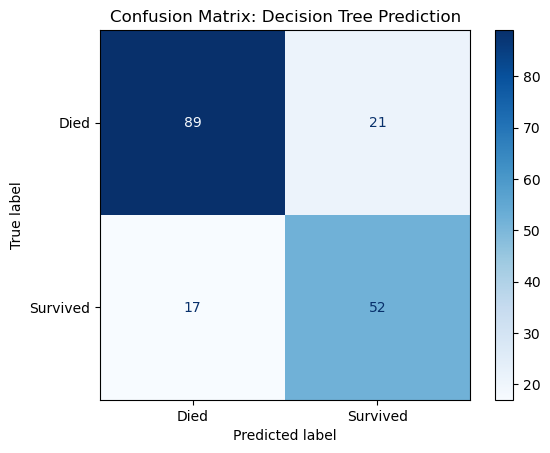

In [16]:
# Plot Confusion Matrix
disp = ConfusionMatrixDisplay.from_estimator( 
    model,             # <--- ADD THIS HERE
    X_test, 
    y_test, 
    display_labels=['Died', 'Survived'], 
    cmap='Blues'
)
plt.title('Confusion Matrix: Decision Tree Prediction')
plt.show()